# Nonlinear complex nudging gradient test

The force is
$$
F(t,u,\bar u)=\bigl[K_s(t)+\rho S+i\eta S\bigr]u
+g|u|^2\odot u+\xi S\bar u,
\qquad
S=\begin{pmatrix}0&1\\-1&0\end{pmatrix},
$$
where all parameters are real and
$$
K_s(t)=
\begin{pmatrix}
\omega_0+\alpha\cos(\Omega t)&-J+\beta\sin(\Omega t)\\
-J+\beta\sin(\Omega t)&\omega_1-\alpha\cos(\Omega t)
\end{pmatrix}
=K_s(t)^T.
$$

Treating $u$ and $\bar u$ as independent, the variation of the Kerr term is
$$
\delta\bigl(|u|^2\odot u\bigr)
=2|u|^2\odot\delta u+u^2\odot\delta\bar u.
$$
Thus $\delta F=F_u\,\delta u+F_{\bar u}\,\delta\bar u$, with
$$
F_u=K_s(t)+\rho S+i\eta S+2g\,\operatorname{diag}(|u|^2),
\qquad
F_{\bar u}=g\,\operatorname{diag}(u^2)+\xi S.
$$

Since $S^T=-S$, the defects in the three nonlinear conditions of Theorem 7.1 are
$$
\begin{aligned}
F(t,\bar u,u)-\overline{F(t,u,\bar u)}
&=2i\eta S\bar u,\\
F_u^T-\overline{F_u}
&=-2\rho S,\\
\overline{F_{\bar u}}^{\,T}-\overline{F_{\bar u}}
&=-2\xi S.
\end{aligned}
$$

| Force term | Condition it breaks when its coefficient is nonzero |
|---|---|
| $i\eta S u$ | Conjugation time-reversal symmetry: $F(t,\bar u,u)=\overline{F(t,u,\bar u)}$ |
| $\rho S u$ | First tangent condition: $F_u^T=\overline{F_u}$ |
| $\xi S\bar u$ | Second tangent condition: $\overline{F_{\bar u}}^{\,T}=\overline{F_{\bar u}}$ |

Each term preserves the other two conditions. The real symmetric term $K_s(t)u$
and real Kerr term $g|u|^2\odot u$ preserve all three. The valid case has
$\eta=\rho=\xi=0$; each failure case switches on only one of these coefficients.


### Setup
Imports, time grid, tolerances, nudging amplitude $\epsilon=10^{-6}$, parameter labels, the antisymmetric matrix $S$, and cost weights.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson

T = 5.0
Nt = 801
rtol = 1e-10
atol = 1e-12
nudging_epsilon = 1e-6
t_grid = np.linspace(0.0, T, Nt)

initial_condition_names = ["Re u0[0]", "Re u0[1]", "Im u0[0]", "Im u0[1]"]
force_parameter_names = ["w0", "w1", "J", "alpha", "beta", "Omega", "g", "eta", "rho", "xi"]
drive_parameter_names = ["A0", "A1", "omega_f", "phase_f"]
parameter_names = initial_condition_names + force_parameter_names + drive_parameter_names

S_skew = np.array([[0.0, 1.0], [-1.0, 0.0]])
q_traj = 0.20
q_T = 0.70
u_target = np.array([0.08 + 0.10j, -0.06 - 0.20j])
np.set_printoptions(precision=6, suppress=False)

### Force, Wirtinger Jacobians, and derivatives
`make_parameters` switches on at most one of $\eta,\rho,\xi$, each of which breaks exactly one theorem condition.

`F` combines:
- the linear part $K(t)=K_s(t)+(\rho+i\eta)S$;
- the Kerr term $g|u|^2u$;
- the conjugate coupling $\xi S\bar u$.

`F_u` and `F_ubar` are the Wirtinger Jacobians from the introduction. They are used only by the digital adjoint and the diagnostics.

In [2]:
def make_parameters(eta=0.0, rho=0.0, xi=0.0):
    return np.array(
        [0.65, -0.18, 0.12, 0.20]
        + [0.30, 0.65, 0.40, 0.12, 0.10, 0.90, 0.55, eta, rho, xi]
        + [0.08, -0.05, 0.75, 0.40],
        dtype=float,
    )


def unpack(p):
    return dict(zip(parameter_names, p))


def initial_condition(p):
    return np.asarray(p[:2] + 1j * p[2:4], dtype=complex)


def K(t, p):
    p = unpack(p)
    ct, st = np.cos(p["Omega"] * t), np.sin(p["Omega"] * t)
    symmetric = np.array([
        [p["w0"] + p["alpha"] * ct, -p["J"] + p["beta"] * st],
        [-p["J"] + p["beta"] * st, p["w1"] - p["alpha"] * ct],
    ])
    return symmetric + (p["rho"] + 1j * p["eta"]) * S_skew


def F(t, u, p):
    pars = unpack(p)
    return K(t, p) @ u + pars["g"] * np.abs(u)**2 * u + pars["xi"] * (S_skew @ u.conj())


def F_u(t, u, p):
    return K(t, p) + 2.0 * unpack(p)["g"] * np.diag(np.abs(u)**2)


def F_ubar(t, u, p):
    pars = unpack(p)
    return pars["g"] * np.diag(u**2) + pars["xi"] * S_skew


def dF_dp(t, u, p, name):
    pars = unpack(p)
    ct, st = np.cos(pars["Omega"] * t), np.sin(pars["Omega"] * t)
    if name == "w0":
        return np.array([u[0], 0.0])
    if name == "w1":
        return np.array([0.0, u[1]])
    if name == "J":
        return -u[::-1]
    if name == "alpha":
        return ct * np.array([u[0], -u[1]])
    if name == "beta":
        return st * u[::-1]
    if name == "Omega":
        return -pars["alpha"] * t * st * np.array([u[0], -u[1]]) + pars["beta"] * t * ct * u[::-1]
    if name == "g":
        return np.abs(u)**2 * u
    if name == "eta":
        return 1j * (S_skew @ u)
    if name == "rho":
        return S_skew @ u
    if name == "xi":
        return S_skew @ u.conj()
    raise KeyError(name)


def drive(t, p):
    pars = unpack(p)
    wt, phase = pars["omega_f"] * t, pars["phase_f"]
    return np.array([
        pars["A0"] * np.exp(1j * phase) * np.sin(wt),
        pars["A1"] * np.exp(-1j * phase) * np.cos(wt),
    ])


def drive_dp(t, p, name):
    pars = unpack(p)
    wt, phase = pars["omega_f"] * t, pars["phase_f"]
    if name == "A0":
        return np.array([np.exp(1j * phase) * np.sin(wt), 0.0])
    if name == "A1":
        return np.array([0.0, np.exp(-1j * phase) * np.cos(wt)])
    if name == "omega_f":
        return t * np.array([
            pars["A0"] * np.exp(1j * phase) * np.cos(wt),
            -pars["A1"] * np.exp(-1j * phase) * np.sin(wt),
        ])
    if name == "phase_f":
        return np.array([1j, -1j]) * drive(t, p)
    raise KeyError(name)

### Cost and forward solve
The cost derivatives use the standard Wirtinger normalization, so gradients below carry $2\,\mathrm{Re}$. `integrate` wraps `solve_ivp` with DOP853, an explicit method that handles the non-holomorphic right-hand side directly on the complex state.

In [3]:
def u_reference(t):
    return np.array([0.15 * np.exp(0.30j * t), -0.10j * np.exp(-0.20j * t)])


def theta_value(u, t):
    residual = u - u_reference(t)
    return 0.5 * q_traj * np.vdot(residual, residual).real


def theta_u(u, t):
    # Standard Wirtinger derivative of (q/2) |u-r|^2.
    return 0.5 * q_traj * np.conjugate(u - u_reference(t))


def psi_value(u):
    residual = u - u_target
    return 0.5 * q_T * np.vdot(residual, residual).real


def psi_u(u):
    return 0.5 * q_T * np.conjugate(u - u_target)


def integrate(rhs, initial):
    # Explicit DOP853 handles the non-holomorphic RHS directly as a complex ODE.
    sol = solve_ivp(
        rhs, (0.0, T), np.asarray(initial, dtype=complex),
        t_eval=t_grid, dense_output=True, method="DOP853", rtol=rtol, atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def solve_forward(p):
    return integrate(lambda t, u: 1j * (F(t, u, p) - drive(t, p)), initial_condition(p))


def objective(p):
    forward = solve_forward(p)
    values = [theta_value(forward.y[:, k], t) for k, t in enumerate(t_grid)]
    return simpson(values, x=t_grid) + psi_value(forward.y[:, -1])

### Digital adjoint and the conjugation-nudging experiment
`solve_digital_adjoint` integrates the exact $c$-adjoint, which needs both transposed Wirtinger terms: $F_u^Tc$ and $F_{\bar u}^\dagger\bar c$.

`physical_nudged_adjoint` uses only $F$. The reversed run starts at $\overline{u(T)}$ with drive $\overline{f(T-\tau)}$; this is the conjugation TRM. The nudged run adds:
- $\epsilon c_0$ to the initial state;
- $-\epsilon\theta_u$ to the drive.

The difference quotient estimates $c$.

In [4]:
class DenseSolution:
    def __init__(self, t, y, sol):
        self.t = t
        self.y = y
        self.sol = sol


def solve_digital_adjoint(p, forward):
    c0 = 1j * psi_u(forward.y[:, -1])

    def rhs(tau, c):
        r = T - tau
        u = forward.sol(r)
        return 1j * (
            F_u(r, u, p).T @ c
            + F_ubar(r, u, p).conj().T @ c.conj()
            + theta_u(u, r)
        )

    return integrate(rhs, c0)


def physical_nudged_adjoint(p, forward, epsilon=nudging_epsilon, return_runs=False):
    if epsilon == 0:
        raise ValueError("A nonzero nudging amplitude is required for the difference quotient.")
    w0 = forward.y[:, -1].conj()
    c0 = 1j * psi_u(forward.y[:, -1])

    def reverse_rhs(eps):
        def rhs(tau, w):
            r = T - tau
            source = drive(r, p).conj() - eps * theta_u(forward.sol(r), r)
            # Full nonlinear hardware: same F and p; no tangent operators.
            return 1j * (F(r, w, p) - source)
        return rhs

    reverse = integrate(reverse_rhs(0.0), w0)
    nudged = integrate(reverse_rhs(epsilon), w0 + epsilon * c0)
    physical = DenseSolution(
        t_grid, (nudged.y - reverse.y) / epsilon,
        lambda tau: (nudged.sol(tau) - reverse.sol(tau)) / epsilon,
    )
    if return_runs:
        return physical, reverse, nudged
    return physical

### Gradient assembly and diagnostics
The overlap integrals use the bilinear product $c^TF_p$ (no conjugation of $c$) inside $2\,\mathrm{Re}$. `condition_defects` evaluates the three theorem conditions along the forward trajectory:
- conjugation symmetry of $F$;
- $F_u^T=\overline{F_u}$;
- $\overline{F_{\bar u}}^T=\overline{F_{\bar u}}$.

In [ ]:
def gradient_from_adjoint(p, forward, adjoint):
    cT = adjoint.sol(T)
    gradient = list(2.0 * cT.imag) + list(2.0 * cT.real)
    c_forward = adjoint.sol(T - t_grid)

    for name in force_parameter_names:
        # Bilinear c^T F_p equals <conj(c), F_p>_C; do not conjugate c here.
        values = [
            2.0 * np.real(c_forward[:, k] @ dF_dp(t, forward.y[:, k], p, name))
            for k, t in enumerate(t_grid)
        ]
        gradient.append(simpson(values, x=t_grid))

    for name in drive_parameter_names:
        values = [
            -2.0 * np.real(c_forward[:, k] @ drive_dp(t, p, name))
            for k, t in enumerate(t_grid)
        ]
        gradient.append(simpson(values, x=t_grid))

    return np.array(gradient, dtype=float)


def taylor_errors(p, gradients, h_values, direction):
    chi0 = objective(p)
    p_scale = np.mean(np.abs(p))
    errors = {label: [] for label in gradients}
    for h in h_values:
        delta = h * p_scale * direction
        chi_delta = objective(p + delta)
        for label, gradient in gradients.items():
            errors[label].append(abs(chi_delta - chi0 - gradient @ delta))
    return {label: np.array(values) for label, values in errors.items()}


def relative_field_error(reference, estimate):
    numerator = simpson(np.sum(np.abs(estimate - reference)**2, axis=0), x=t_grid)
    denominator = simpson(np.sum(np.abs(reference)**2, axis=0), x=t_grid)
    return np.sqrt(numerator / denominator)


def condition_defects(p, forward):
    defects = []
    for t in t_grid[::20]:
        u = forward.sol(t)
        A, B = F_u(t, u, p), F_ubar(t, u, p)
        defects.append([
            np.linalg.norm(F(t, u.conj(), p) - F(t, u, p).conj()),
            np.linalg.norm(A.T - A.conj()),
            np.linalg.norm(B.conj().T - B.conj()),
        ])
    return np.max(defects, axis=0)

### Run the four cases
There is one valid case and one case per broken condition. The printout shows which defect is nonzero and whether the reversed run still retraces the forward one. The TRM breaks only for $\eta\neq0$; for $\rho$ and $\xi$ the TRM holds but the adjoint is still wrong.

In [ ]:
def solve_case(label, eta=0.0, rho=0.0, xi=0.0):
    p = make_parameters(eta=eta, rho=rho, xi=xi)
    forward = solve_forward(p)
    digital = solve_digital_adjoint(p, forward)
    physical, reverse, nudged = physical_nudged_adjoint(p, forward, return_runs=True)
    grad_digital = gradient_from_adjoint(p, forward, digital)
    grad_physical = gradient_from_adjoint(p, forward, physical)
    return {
        "label": label, "p": p, "forward": forward, "digital": digital,
        "physical": physical, "reverse": reverse, "nudged": nudged,
        "grad_digital": grad_digital, "grad_physical": grad_physical,
        "defects": condition_defects(p, forward),
        "trm_error": relative_field_error(forward.sol(T - t_grid).conj(), reverse.y),
        "field_error": relative_field_error(digital.y, physical.y),
        "gradient_error": np.linalg.norm(grad_physical - grad_digital) / np.linalg.norm(grad_digital),
    }


cases = [
    solve_case("valid"),
    solve_case("TRM broken", eta=0.18),
    solve_case("F_u broken", rho=0.18),
    solve_case("F_ubar broken", xi=0.15),
]

for result in cases:
    print(result["label"])
    print("  max force-conjugastion / F_u / F_ubar defects:", result["defects"])
    print(f"  TRM relative trajectory error: {result['trm_error']:.3e}")
    print(f"  relative physical/digital field error: {result['field_error']:.3e}")
    print(f"  relative physical/digital gradient error: {result['gradient_error']:.3e}")
    print()

valid
  max force-conjugation / F_u / F_ubar defects: [0. 0. 0.]
  TRM relative trajectory error: 7.252e-11
  relative physical/digital field error: 2.342e-07
  relative physical/digital gradient error: 2.333e-07

TRM broken
  max force-conjugation / F_u / F_ubar defects: [0.257726 0.       0.      ]
  TRM relative trajectory error: 5.288e-01
  relative physical/digital field error: 5.522e-01
  relative physical/digital gradient error: 8.945e-01

F_u broken
  max force-conjugation / F_u / F_ubar defects: [0.       0.509117 0.      ]
  TRM relative trajectory error: 7.684e-11
  relative physical/digital field error: 4.308e-01
  relative physical/digital gradient error: 4.720e-01

F_ubar broken
  max force-conjugation / F_u / F_ubar defects: [0.       0.       0.424264]
  TRM relative trajectory error: 9.505e-11
  relative physical/digital field error: 2.960e-01
  relative physical/digital gradient error: 2.751e-01



### Taylor test of the nudged physical gradient
Only the valid case should give an $h^2$ slope. The perturbation direction also moves the condition-breaking parameters, which is fine because the gradient is evaluated at the base point.

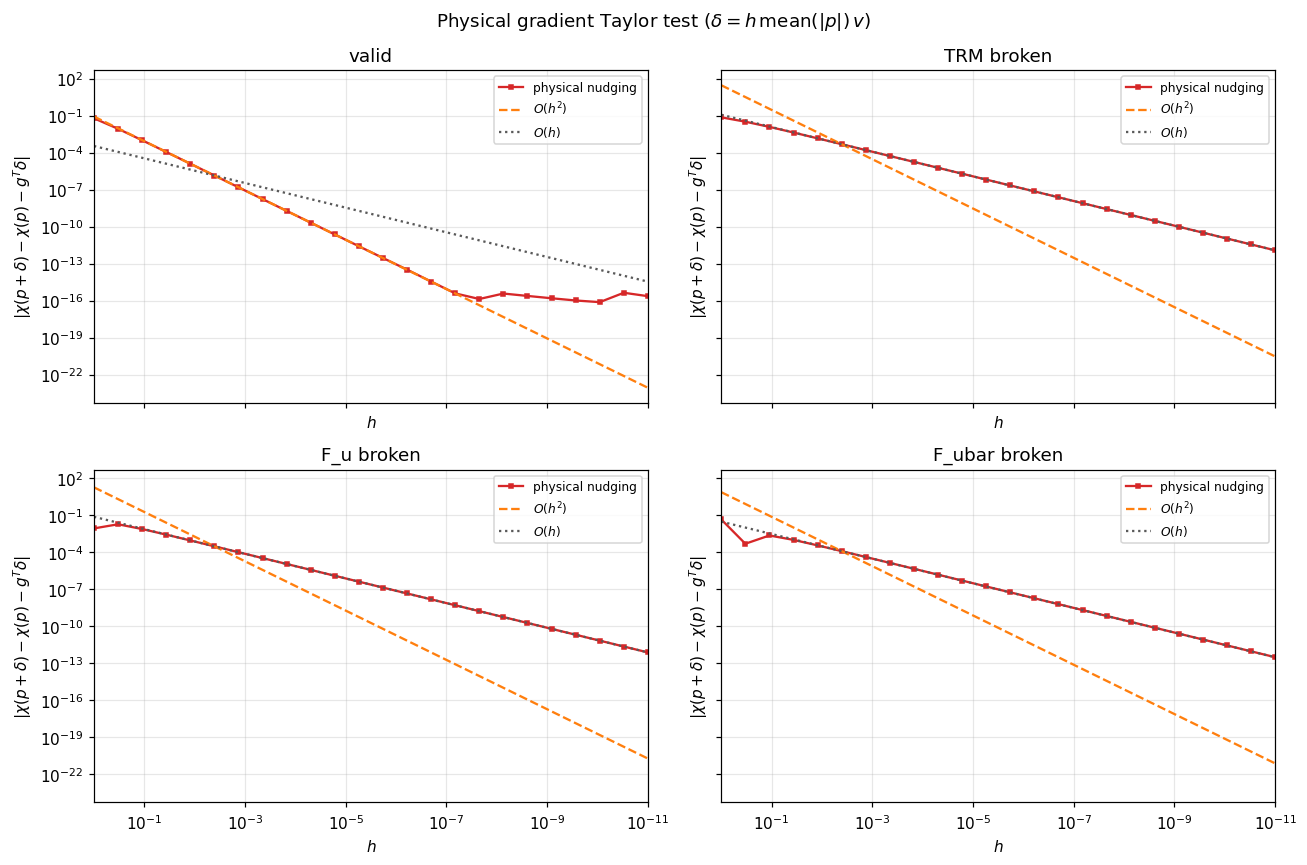

In [ ]:
rng = np.random.default_rng(7)
direction = rng.normal(size=len(parameter_names))
direction /= np.linalg.norm(direction)
h_values = np.logspace(0, -11, 24)

# Perturbations include condition-breaking parameters. The derivative is evaluated
# at the base point; this does not require the perturbed points to obey the theorem.
for result in cases:
    result["taylor"] = taylor_errors(
        result["p"],
        {"physical nudging": result["grad_physical"], "digital adjoint": result["grad_digital"]},
        h_values, direction,
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, result in zip(axes.flat, cases):
    errors = result["taylor"]["physical nudging"]
    anchor = 5
    ax.loglog(h_values, errors, "s-", ms=3, color="tab:red", label="physical nudging")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor])**2,
              "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor]),
              ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.set_title(result["label"])
    ax.set_xlabel(r"$h$")
    ax.set_ylabel(r"$|\chi(p+\delta)-\chi(p)-g^T\delta|$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle(r"Physical gradient Taylor test")
plt.tight_layout()
plt.show()

### Nudging-amplitude sweep
The valid case should converge as $O(\epsilon)$ until roundoff. The broken cases should level off at order one for every $\epsilon$, which confirms that the failure is structural.

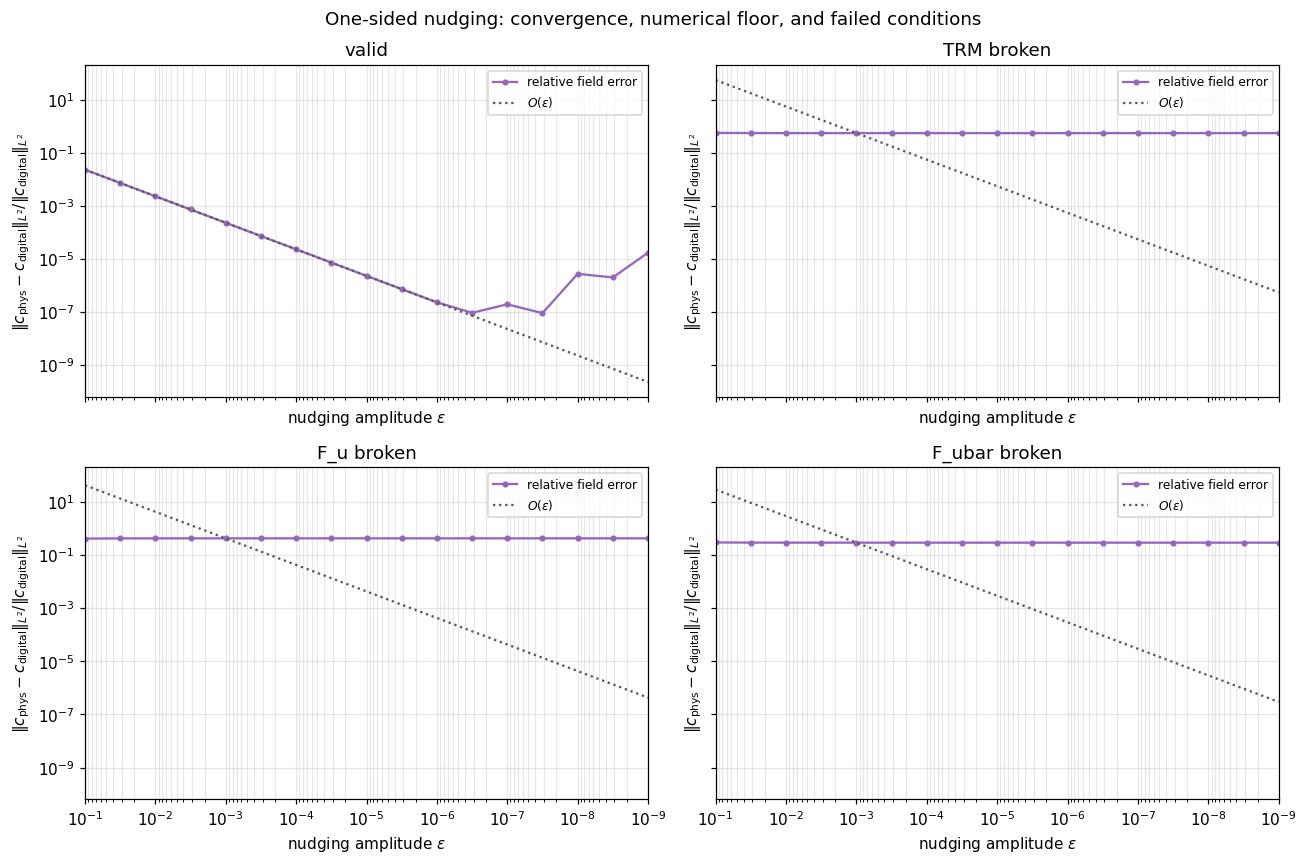

In [8]:
epsilon_values = np.logspace(-1, -9, 17)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, result in zip(axes.flat, cases):
    errors = []
    for epsilon in epsilon_values:
        physical = physical_nudged_adjoint(result["p"], result["forward"], epsilon=epsilon)
        errors.append(relative_field_error(result["digital"].y, physical.y))
    result["epsilon_errors"] = np.array(errors)
    anchor = 4
    ax.loglog(epsilon_values, errors, "o-", ms=3, color="tab:purple", label="relative field error")
    ax.loglog(epsilon_values, errors[anchor] * epsilon_values / epsilon_values[anchor],
              ":", color="0.35", label=r"$O(\epsilon)$")
    ax.set_xlim(epsilon_values[0], epsilon_values[-1])
    ax.set_title(result["label"])
    ax.set_xlabel(r"nudging amplitude $\epsilon$")
    ax.set_ylabel(r"$\|c_{\rm phys}-c_{\rm digital}\|_{L^2}/\|c_{\rm digital}\|_{L^2}$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("One-sided nudging: convergence, numerical floor, and failed conditions")
plt.tight_layout()
plt.show()

### Control: Taylor test of the digital adjoint
The exact adjoint should give an $h^2$ slope in all four cases.

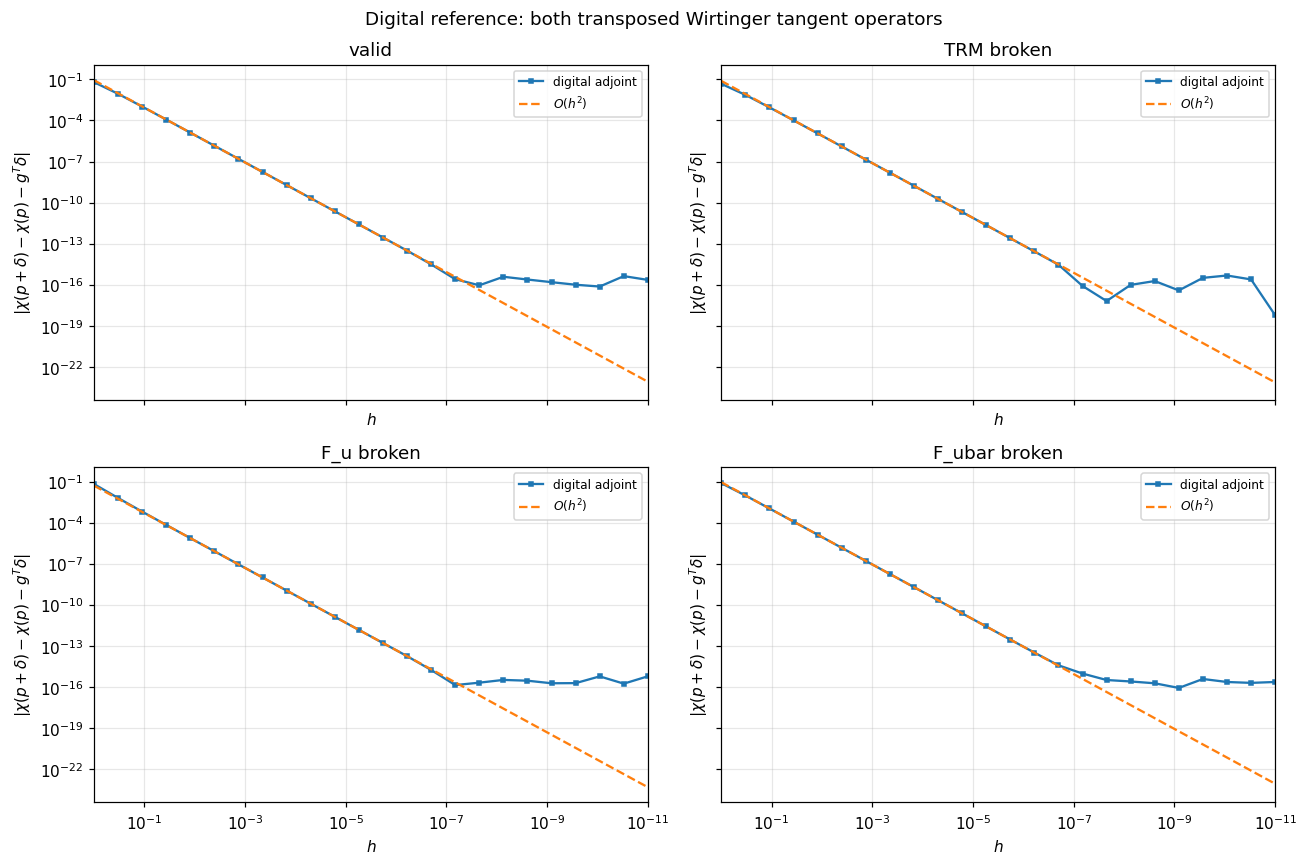

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, result in zip(axes.flat, cases):
    errors = result["taylor"]["digital adjoint"]
    anchor = 5
    ax.loglog(h_values, errors, "s-", ms=3, color="tab:blue", label="digital adjoint")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor])**2,
              "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.set_title(result["label"])
    ax.set_xlabel(r"$h$")
    ax.set_ylabel(r"$|\chi(p+\delta)-\chi(p)-g^T\delta|$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Digital reference: both transposed Wirtinger tangent operators")
plt.tight_layout()
plt.show()

### Automated checks
This cell turns the expectations above into assertions:
- Each case breaks exactly the intended condition.
- The digital gradient matches central finite differences.
- The valid physical gradient passes the finite-difference, Taylor ($\approx2$), and nudging-order ($\approx1$) checks.
- Every broken case fails with Taylor order $\approx1$ and field error above $10^{-2}$ at the seven smallest $\epsilon$ values.

In [10]:
def finite_difference_gradient(p, step=1e-5):
    gradient = np.empty_like(p)
    for j in range(p.size):
        delta = np.zeros_like(p)
        delta[j] = step * max(1.0, abs(p[j]))
        gradient[j] = (objective(p + delta) - objective(p - delta)) / (2.0 * delta[j])
    return gradient


def fitted_order(x, errors, lower, upper):
    mask = (x >= lower) & (x <= upper)
    return np.polyfit(np.log(x[mask]), np.log(errors[mask]), 1)[0]


expected_defects = [
    (False, False, False), (True, False, False),
    (False, True, False), (False, False, True),
]
for result, expected in zip(cases, expected_defects):
    np.testing.assert_array_equal(result["defects"] > 1e-10, expected)
    fd = finite_difference_gradient(result["p"])
    result["grad_finite_difference"] = fd
    np.testing.assert_allclose(result["grad_digital"], fd, rtol=2e-5, atol=2e-7)
    digital_order = fitted_order(h_values, result["taylor"]["digital adjoint"], 1e-4, 1e-2)
    assert 1.8 < digital_order < 2.2, (result["label"], digital_order)
    print(f"{result['label']}: digital Taylor order={digital_order:.3f}, "
          f"max component FD error={np.max(np.abs(result['grad_digital'] - fd)):.3e}")

valid = cases[0]
np.testing.assert_allclose(valid["grad_physical"], valid["grad_finite_difference"], rtol=2e-4, atol=2e-6)
assert valid["trm_error"] < 1e-7
assert valid["field_error"] < 1e-5
assert valid["gradient_error"] < 1e-5
physical_order = fitted_order(h_values, valid["taylor"]["physical nudging"], 1e-4, 1e-2)
epsilon_order = fitted_order(epsilon_values, valid["epsilon_errors"], 1e-4, 1e-2)
assert 1.8 < physical_order < 2.2, physical_order
assert 0.8 < epsilon_order < 1.2, epsilon_order
assert cases[1]["trm_error"] > 1e-2
for result in cases[2:]:
    assert result["trm_error"] < 1e-7
for result in cases[1:]:
    assert result["field_error"] > 1e-2
    assert result["gradient_error"] > 1e-2
    assert np.min(result["epsilon_errors"][-7:]) > 1e-2
    physical_order_broken = fitted_order(h_values, result["taylor"]["physical nudging"], 1e-4, 1e-2)
    assert 0.8 < physical_order_broken < 1.2, (result["label"], physical_order_broken)

print(f"valid physical Taylor order={physical_order:.3f}; nudging order={epsilon_order:.3f}")
print("All condition-isolation, finite-difference, Taylor, and nudging checks passed.")

valid: digital Taylor order=2.000, max component FD error=3.723e-10
TRM broken: digital Taylor order=2.000, max component FD error=4.581e-10
F_u broken: digital Taylor order=2.001, max component FD error=1.206e-09
F_ubar broken: digital Taylor order=2.000, max component FD error=5.712e-10
valid physical Taylor order=2.000; nudging order=1.000
All condition-isolation, finite-difference, Taylor, and nudging checks passed.
